In [ ]:

import pandas as pd
from pathlib import Path
import numpy as np
import itertools
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:


PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_path = PROJECT_DIR / "THORAX_radiomics_features.csv"

# === SELEZIONARE PROTOCOLLO E RIPETIZIONE ===
PROTOCOLLO_SCELTO = "Thorax_HD_HR_1.00_Bl60_A0"  # Cambia con il protocollo 
RIPETIZIONE_SCELTA = "rep_1"  # Cambia con la ripetizione 
ROI_SCELTA = None  # numero (es. 1) per vedere solo una ROI, oppure None per tutte

if not csv_path.exists():
    print(f"File non trovato: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    
    # Filtra per protocollo e ripetizione
    df_filtrato = df[(df['protocol'] == PROTOCOLLO_SCELTO) & (df['repeat'] == RIPETIZIONE_SCELTA)]
    
    # Filtra anche per ROI se specificata
    if ROI_SCELTA is not None:
        df_filtrato = df_filtrato[df_filtrato['roi'] == ROI_SCELTA]
    
    if df_filtrato.empty:
        print(f"Nessun dato trovato per {PROTOCOLLO_SCELTO} / {RIPETIZIONE_SCELTA}")
        print("\nProtocolli disponibili:")
        print(df['protocol'].unique())
    else:
        print(f"=== {PROTOCOLLO_SCELTO} / {RIPETIZIONE_SCELTA} ===")
        print(f"Trovate {len(df_filtrato)} ROI\n")
        
        # opzioni di visualizzazione per vedere tutto
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)
        
        # Mostra tutte le feature per le ROI selezionate
        print(df_filtrato)
        
        print(f"\n✓ Totale feature estratte: {len([col for col in df.columns if col.startswith('original_')])}")

=== Thorax_HD_HR_1.00_Bl60_A0 / rep_1 ===
Trovate 19 ROI

    original_firstorder_10Percentile  original_firstorder_90Percentile  \
0                             -105.0                             340.0   
1                             -648.5                            -198.0   
2                            -1263.0                             547.5   
3                            -1939.4                             591.7   
4                            -1114.7                             232.7   
5                              -49.0                             350.0   
6                             -558.0                            -101.3   
7                            -1372.0                            -224.3   
8                            -1163.7                             640.7   
9                            -1472.0                              58.4   
10                           -1984.7                             747.7   
11                           -1446.0                  

# CV calcolo

In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_path = PROJECT_DIR / "THORAX_radiomics_features.csv"

if not csv_path.exists():
    print(f"File non trovato: {csv_path}")
else:
    df = pd.read_csv(csv_path)

    feature_cols = [col for col in df.columns if col.startswith('original_')]

    print(f"Analisi CV su {len(feature_cols)} feature radiomiche")
    print(f"Protocolli: {df['protocol'].nunique()}")
    print(f"ROI per protocollo: {df['roi'].nunique()}\n")

    risultati_cv = []

    for protocollo in sorted(df['protocol'].unique()):
        df_prot = df[df['protocol'] == protocollo]

        for roi in sorted(df_prot['roi'].unique()):
            df_roi = df_prot[df_prot['roi'] == roi]

            n_rep = len(df_roi)
            if n_rep < 2:
                continue

            for feature in feature_cols:
                values = df_roi[feature].values

                if np.any(~np.isfinite(values)):
                    continue

                mean = np.mean(values)
                std = np.std(values, ddof=1)

                if abs(mean) < 1e-10:
                    cv = np.nan
                else:
                    cv = (std / abs(mean)) * 100

                risultati_cv.append({
                    'protocol': protocollo,
                    'roi': roi,
                    'feature': feature,
                    'mean': mean,
                    'std': std,
                    'cv_percent': cv,
                    'n_repetitions': n_rep
                })

    df_cv = pd.DataFrame(risultati_cv)

    out_cv = PROJECT_DIR / "THORAX_coefficienti_variazione.csv"
    df_cv.to_csv(out_cv, index=False)

    print(f"✓ Calcolati {len(df_cv)} CV")
    print(f"✓ Salvato in: {out_cv}")


Analisi CV su 93 feature radiomiche
Protocolli: 18
ROI per protocollo: 19

✓ Calcolati 31806 CV
✓ Salvato in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_coefficienti_variazione.csv


## Divisione delle features sui protocolli in termini di CV quindi di riproducibilità o ripetibilità

In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_cv = PROJECT_DIR / "THORAX_coefficienti_variazione.csv"

if not csv_cv.exists():
    print("File CV non trovato.")
else:
    df_cv = pd.read_csv(csv_cv)

    # Percentuali di feature in 4 fasce: <5, 5–10, 10–20, ≥20
    results = []

    for protocol in sorted(df_cv['protocol'].unique()):
        df_p = df_cv[df_cv['protocol'] == protocol]
        total = len(df_p)

        cv_lt5 = (df_p['cv_percent'] < 5).sum()
        cv_lt10 = (df_p['cv_percent'] < 10).sum()
        cv_lt20 = (df_p['cv_percent'] < 20).sum()
        cv_ge20 = (df_p['cv_percent'] >= 20).sum()

        results.append({
            'protocol': protocol,
            'perc_CV_<5': 100 * cv_lt5 / total,
            'perc_CV_5_10': 100 * (cv_lt10 - cv_lt5) / total,
            'perc_CV_10_20': 100 * (cv_lt20 - cv_lt10) / total,
            'perc_CV_≥20': 100 * cv_ge20 / total,
        })

    df_cv_summary = pd.DataFrame(results)
    out_summary = PROJECT_DIR / "THORAX_CV_summary_per_protocol.csv"
    df_cv_summary.to_csv(out_summary, index=False)

    print("=== RIPRODUCIBILITÀ PER PROTOCOLLO (CV) ===\n")
    print(df_cv_summary.round(1))
    print(f"\n✓ Salvato riassunto in: {out_summary}")


=== RIPRODUCIBILITÀ PER PROTOCOLLO (CV) ===

                          protocol  perc_CV_<5  perc_CV_5_10  perc_CV_10_20  \
0        Thorax_HD_HR_1.00_Bl60_A0        71.8          10.0            8.4   
1        Thorax_HD_HR_1.00_Bl60_A3        71.1           9.5            8.5   
2        Thorax_HD_HR_1.00_Br40_A0        68.6          13.5           10.4   
3        Thorax_HD_HR_1.00_Br40_A3        67.6          13.0           11.2   
4        Thorax_HD_HR_1.00_Br60_A0        68.4          10.6            9.9   
5        Thorax_HD_HR_1.00_Br60_A3        69.0          10.1           10.0   
6   Thorax_LD_LowDose_1,00_Bl60_A0        60.7          19.5           12.0   
7   Thorax_LD_LowDose_1,00_Bl60_A3        43.9          22.9           20.4   
8   Thorax_LD_LowDose_1,00_Br40_A0        63.4          14.8           12.8   
9   Thorax_LD_LowDose_1,00_Br40_A3        60.9          15.6           12.8   
10  Thorax_LD_LowDose_1,00_Br60_A0        55.4          20.6           17.0   
11  Tho

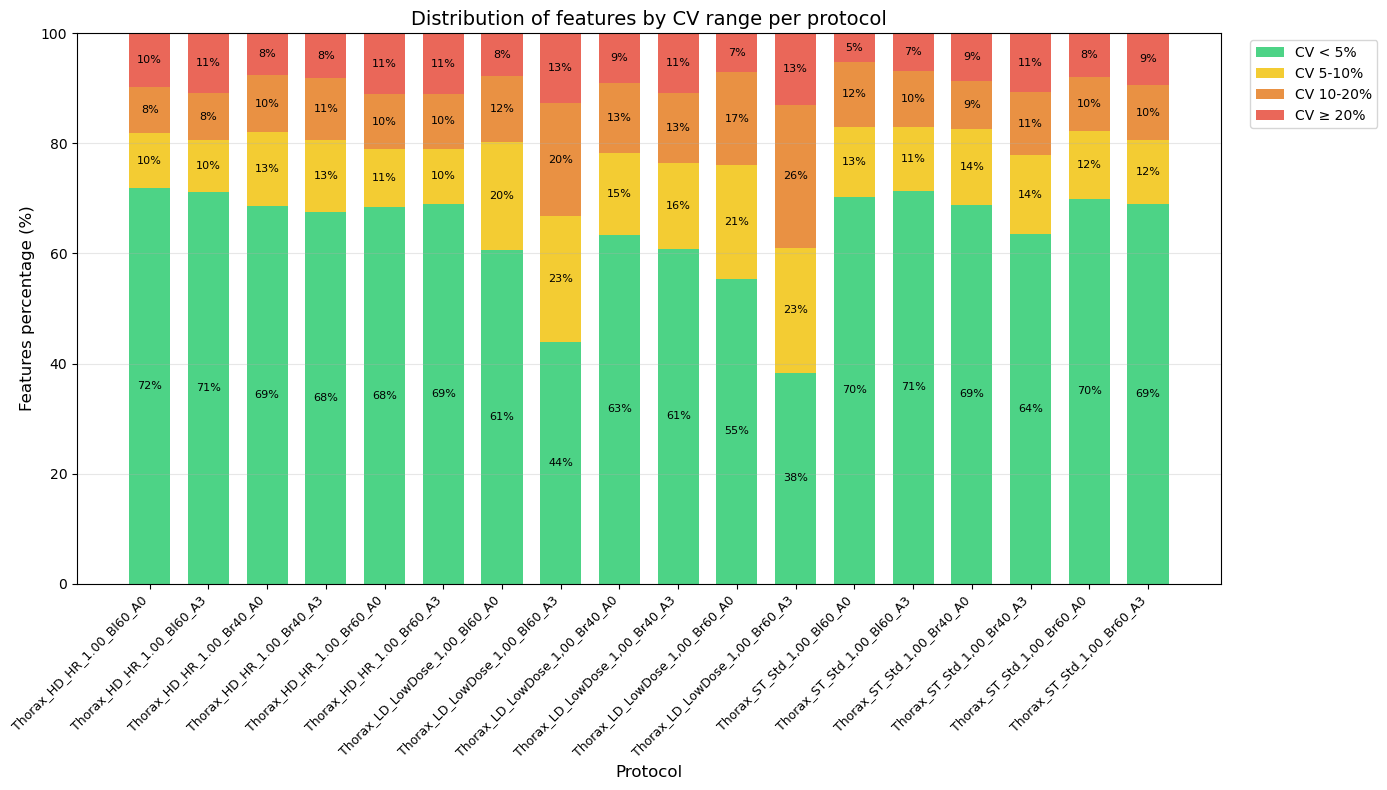

✓ Figura CV salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CV_stacked_per_protocol.png


In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_cv = PROJECT_DIR / "THORAX_coefficienti_variazione.csv"

df_cv = pd.read_csv(csv_cv)

results = []
for protocol in sorted(df_cv['protocol'].unique()):
    df_p = df_cv[df_cv['protocol'] == protocol]
    total = len(df_p)

    cv_lt5 = (df_p['cv_percent'] < 5).sum()
    cv_lt10 = (df_p['cv_percent'] < 10).sum()
    cv_lt20 = (df_p['cv_percent'] < 20).sum()
    cv_ge20 = (df_p['cv_percent'] >= 20).sum()

    results.append({
        'protocol': protocol,
        'CV < 5%': 100 * cv_lt5 / total,
        'CV 5-10%': 100 * (cv_lt10 - cv_lt5) / total,
        'CV 10-20%': 100 * (cv_lt20 - cv_lt10) / total,
        'CV ≥ 20%': 100 * cv_ge20 / total
    })

df_results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(14, 8))

categories = ['CV < 5%', 'CV 5-10%', 'CV 10-20%', 'CV ≥ 20%']
colors_cat = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

x_pos = np.arange(len(df_results))
bottom = np.zeros(len(df_results))

for cat, color in zip(categories, colors_cat):
    values = df_results[cat].values
    ax.bar(x_pos, values, bottom=bottom, label=cat,
           color=color, alpha=0.85, width=0.7)

    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val > 5:
            ax.text(i, bot + val/2, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8)

    bottom += values

ax.set_xlabel('Protocol', fontsize=12)
ax.set_ylabel('Features percentage (%)', fontsize=12)
ax.set_title('Distribution of features by CV range per protocol',
             fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_results['protocol'], rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

out_png = PROJECT_DIR / "THORAX_CV_stacked_per_protocol.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figura CV salvata in:", out_png)


# ICC Intra-Protocollo



In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_path = PROJECT_DIR / "THORAX_radiomics_features.csv"

def icc_2_k(data):
    """
    ICC(2,k): two-way random, absolute agreement, average measures.
    data: array (n_subjects x k_raters)
    """
    data = np.asarray(data, dtype=float)
    n, k = data.shape

    mean_rows = np.mean(data, axis=1, keepdims=True)
    mean_cols = np.mean(data, axis=0, keepdims=True)
    mean_tot = np.mean(data)

    SSR = k * np.sum((mean_rows - mean_tot)**2)
    SSC = n * np.sum((mean_cols - mean_tot)**2)
    SSE = np.sum((data - mean_rows - mean_cols + mean_tot)**2)

    MSR = SSR / (n - 1)
    MSC = SSC / (k - 1)
    MSE = SSE / ((n - 1) * (k - 1))

    icc = (MSR - MSE) / (MSR + (MSC - MSE) / n)
    return icc

if not csv_path.exists():
    print(f"File non trovato: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    feature_cols = [c for c in df.columns if c.startswith("original_")]
    protocolli = sorted(df["protocol"].unique())

    risultati = []

    for protocol in protocolli:
        df_p = df[df["protocol"] == protocol]

        repeats = sorted(df_p["repeat"].unique())
        rois = sorted(df_p["roi"].unique())

        if len(rois) < 2 or len(repeats) < 2:
            continue

        for feature in feature_cols:
            tab = df_p.pivot_table(
                index="roi",
                columns="repeat",
                values=feature
            )

            tab = tab.dropna(axis=0, how="any")
            n_roi, n_rep = tab.shape

            if n_roi < 2 or n_rep < 2:
                continue

            data = tab.values

            try:
                icc_val = icc_2_k(data)
            except ZeroDivisionError:
                icc_val = np.nan

            risultati.append({
                "protocol": protocol,
                "feature": feature,
                "n_roi": n_roi,
                "n_repetitions": n_rep,
                "icc2_k": icc_val
            })

    df_icc = pd.DataFrame(risultati)
    out_icc = PROJECT_DIR / "THORAX_ICC_intra_protocollo.csv"
    df_icc.to_csv(out_icc, index=False)

    print(f"✓ Calcolati {len(df_icc)} ICC intra-protocollo")
    print(f"✓ Salvato in: {out_icc}")


✓ Calcolati 1674 ICC intra-protocollo
✓ Salvato in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_ICC_intra_protocollo.csv


In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_icc = PROJECT_DIR / "THORAX_ICC_intra_protocollo.csv"

if not csv_icc.exists():
    print("File ICC non trovato.")
else:
    df_icc = pd.read_csv(csv_icc)

    # Statistiche per feature: media ICC sui protocolli e % protocolli con ICC>0.9
    summary = (
        df_icc
        .groupby("feature")["icc2_k"]
        .agg(["mean", "median", "min", "max"])
        .rename(columns={"mean": "icc_mean", "median": "icc_median"})
    )

    # percentuale protocolli con ICC>0.9
    tmp = df_icc.copy()
    tmp["icc_good"] = tmp["icc2_k"] > 0.9
    frac = tmp.groupby("feature")["icc_good"].mean().rename("frac_protocols_ICC>0.9")

    summary = summary.join(frac)

    out_summary_icc = PROJECT_DIR / "THORAX_ICC_summary_per_feature.csv"
    summary.to_csv(out_summary_icc)

    print("=== RIASSUNTO ICC INTRA-PROTOCOLLO PER FEATURE ===")
    print(summary.head(15))
    print(f"\n✓ Salvato in: {out_summary_icc}")


=== RIASSUNTO ICC INTRA-PROTOCOLLO PER FEATURE ===
                                                 icc_mean  icc_median  \
feature                                                                 
original_firstorder_10Percentile                 0.999798    0.999966   
original_firstorder_90Percentile                 0.999778    0.999918   
original_firstorder_Energy                       0.999674    0.999985   
original_firstorder_Entropy                      0.999422    0.999900   
original_firstorder_InterquartileRange           0.999498    0.999871   
original_firstorder_Kurtosis                     0.989558    0.992437   
original_firstorder_Maximum                      0.993897    0.995135   
original_firstorder_Mean                         0.999976    0.999996   
original_firstorder_MeanAbsoluteDeviation        0.999533    0.999951   
original_firstorder_Median                       0.999960    0.999962   
original_firstorder_Minimum                      0.998551    0.998903   


## Distribuzione dei valori di ICC intra-protocollo


N ICC: 1674
ICC min / max: 0.5604599269758077 0.9999990196025688
ICC median: 0.9986798411815789


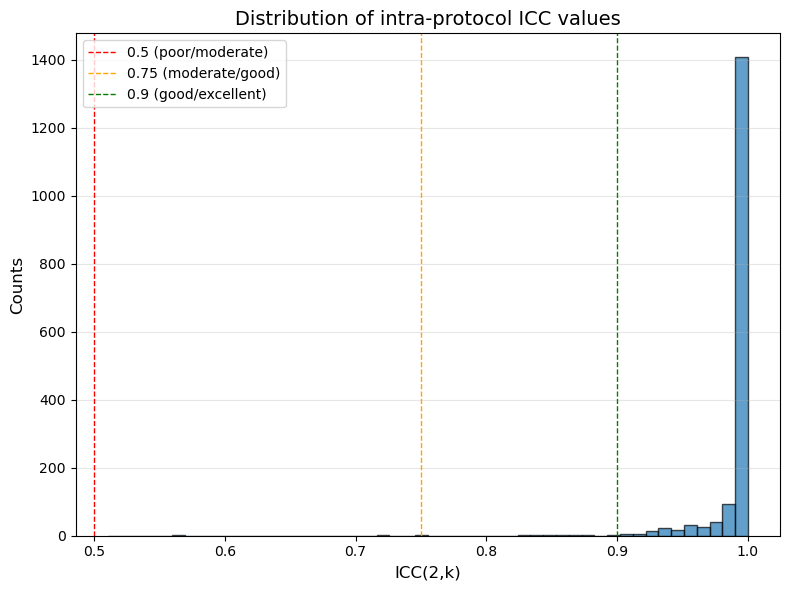

✓ Istogramma ICC salvato in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_ICC_histogram.png


In [ ]:



PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_icc = PROJECT_DIR / "THORAX_ICC_intra_protocollo.csv"

df_icc = pd.read_csv(csv_icc)

icc_values = df_icc["icc2_k"].dropna().values

print("N ICC:", len(icc_values))
print("ICC min / max:", np.min(icc_values), np.max(icc_values))
print("ICC median:", np.median(icc_values))

plt.figure(figsize=(8, 6))
plt.hist(icc_values, bins=50, range=(np.min(icc_values)-0.05, 1), edgecolor="black", alpha=0.7)
plt.axvline(0.5, color="red", linestyle="--", linewidth=1, label="0.5 (poor/moderate)")
plt.axvline(0.75, color="orange", linestyle="--", linewidth=1, label="0.75 (moderate/good)")
plt.axvline(0.9, color="green", linestyle="--", linewidth=1, label="0.9 (good/excellent)")

plt.xlabel("ICC(2,k)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.title("Distribution of intra-protocol ICC values", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)

out_png = PROJECT_DIR / "THORAX_ICC_histogram.png"
plt.tight_layout()
plt.savefig(out_png, dpi=300)
plt.show()

print("✓ Istogramma ICC salvato in:", out_png)


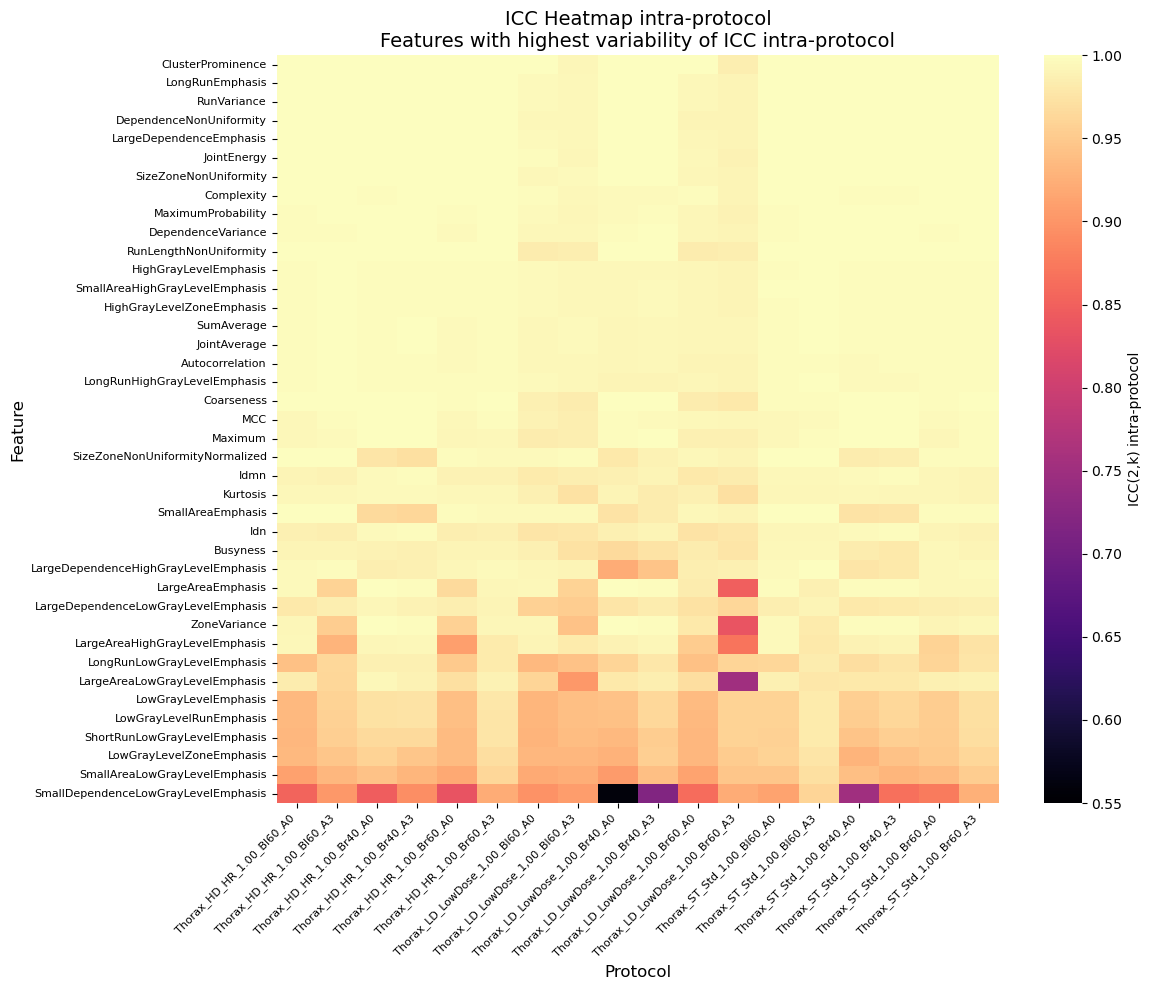

✓ Heatmap ICC salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_ICC_heatmap_top_features.png


In [ ]:


PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_icc = PROJECT_DIR / "THORAX_ICC_intra_protocollo.csv"

df_icc = pd.read_csv(csv_icc)

# Deviazione standard dell'ICC per feature (sui protocolli)
icc_var = (
    df_icc
    .groupby("feature")["icc2_k"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "icc_mean", "std": "icc_std"})
)

# Seleziona le feature con ICC meno "piatto" (std più alta)
n_features = 40  
top_feats = (
    icc_var
    .sort_values("icc_std", ascending=False)
    .head(n_features)
    .index
)

df_sub = df_icc[df_icc["feature"].isin(top_feats)].copy()

# Pivot: righe = feature, colonne = protocol, valori = ICC
icc_pivot = df_sub.pivot_table(
    index="feature",
    columns="protocol",
    values="icc2_k"
)

# Ordina feature per ICC medio 
icc_pivot["icc_mean"] = icc_pivot.mean(axis=1)
icc_pivot = icc_pivot.sort_values("icc_mean", ascending=False)
icc_pivot = icc_pivot.drop(columns=["icc_mean"])

plt.figure(figsize=(12, 10))
sns.heatmap(
    icc_pivot,
    vmin=0.55, vmax=1.0, 
    cmap="magma",
    cbar_kws={"label": "ICC(2,k) intra-protocol"}
)

plt.title("ICC Heatmap intra-protocol\nFeatures with highest variability of ICC intra-protocol",
          fontsize=14)
plt.xlabel("Protocol", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)

yticklabels = [lab.get_text().split("_", 2)[-1] for lab in plt.gca().get_yticklabels()]
plt.gca().set_yticklabels(yticklabels, fontsize=8)

out_png = PROJECT_DIR / "THORAX_ICC_heatmap_top_features.png"
plt.tight_layout()
plt.savefig(out_png, dpi=300)
plt.show()

print("✓ Heatmap ICC salvata in:", out_png)


# CCC Inter-Protocollo

### Generazione della tabella media delle features calcolata sulle 5 ripetizioni dello stesso protocollo

In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_path = PROJECT_DIR / "THORAX_radiomics_features.csv"

df = pd.read_csv(csv_path)

feature_cols = [c for c in df.columns if c.startswith("original_")]

rows = []

for protocol in sorted(df["protocol"].unique()):
    df_p = df[df["protocol"] == protocol]

    for roi in sorted(df_p["roi"].unique()):
        df_r = df_p[df_p["roi"] == roi]

        for feature in feature_cols:
            vals = df_r[feature].values
            if np.any(~np.isfinite(vals)):
                continue

            mean = vals.mean()

            rows.append({
                "protocol": protocol,
                "roi": roi,
                "feature": feature,
                "mean_feature": mean
            })

df_mean = pd.DataFrame(rows)
out_mean = PROJECT_DIR / "THORAX_mean_feature_per_protocol.csv"
df_mean.to_csv(out_mean, index=False)

print(f"✓ Salvato in: {out_mean}")


✓ Salvato in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_mean_feature_per_protocol.csv


In [ ]:


PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
df = pd.read_csv(PROJECT_DIR / "THORAX_mean_feature_per_protocol.csv")

prots = sorted(df["protocol"].unique())

def ccc(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    #cov_xy = np.mean((x - mean_x) * (y - mean_y))
    cov_xy = np.cov(x, y, ddof=1)[0, 1]
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y)**2)

rows = []

for p1, p2 in itertools.combinations(prots, 2):
    for feature in df["feature"].unique():
        df1 = df[(df["protocol"] == p1) & (df["feature"] == feature)]
        df2 = df[(df["protocol"] == p2) & (df["feature"] == feature)]

        merged = pd.merge(df1, df2, on="roi", suffixes=("_p1", "_p2"))
        if len(merged) < 2:
            continue

        x = merged["mean_feature_p1"].values
        y = merged["mean_feature_p2"].values

        coeff = ccc(x, y)

        rows.append({
            "protocol_1": p1,
            "protocol_2": p2,
            "feature": feature,
            "ccc": coeff,
            "n_roi": len(x)
        })

df_ccc = pd.DataFrame(rows)
out_ccc = PROJECT_DIR / "THORAX_CCC_between_protocols.csv"
df_ccc.to_csv(out_ccc, index=False)

print(f"✓ Salvati {len(df_ccc)} CCC in: {out_ccc}")


✓ Salvati 14229 CCC in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_between_protocols.csv


✓ Salvata matrice CCC medio in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_protocols.csv


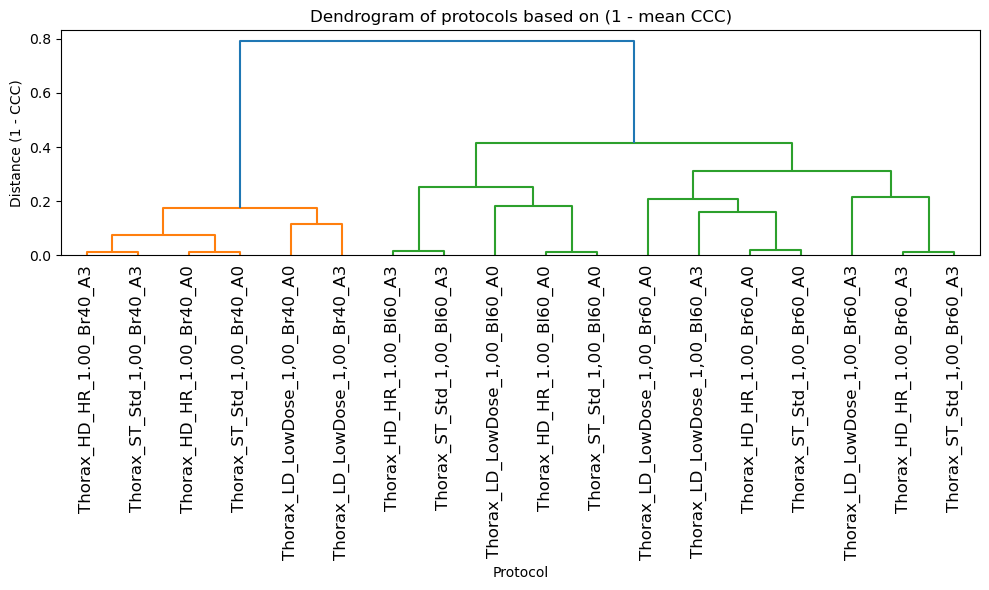

✓ Salvato dendrogramma CCC
✓ Salvato ranking protocolli in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_protocol_ranking.csv

=== TOP PROTOCOLLI PER CCC MEDIO ===
                          protocol  robustness_mean_CCC
4        Thorax_HD_HR_1.00_Br60_A0             0.581330
16      Thorax_ST_Std_1,00_Br60_A0             0.579970
7   Thorax_LD_LowDose_1,00_Bl60_A3             0.566226
13      Thorax_ST_Std_1,00_Bl60_A3             0.563703
17      Thorax_ST_Std_1,00_Br60_A3             0.560816
5        Thorax_HD_HR_1.00_Br60_A3             0.559305
1        Thorax_HD_HR_1.00_Bl60_A3             0.557899
11  Thorax_LD_LowDose_1,00_Br60_A3             0.511975
10  Thorax_LD_LowDose_1,00_Br60_A0             0.510659
0        Thorax_HD_HR_1.00_Bl60_A0             0.498954


In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
df_ccc = pd.read_csv(PROJECT_DIR / "THORAX_CCC_between_protocols.csv")

prots = sorted(set(df_ccc["protocol_1"]).union(df_ccc["protocol_2"]))
P = len(prots)

# Matrice CCC medio
M = np.ones((P, P))

for i, pi in enumerate(prots):
    for j, pj in enumerate(prots):
        if i == j:
            M[i, j] = 1.0
        elif i < j:
            sub = df_ccc[(df_ccc["protocol_1"] == pi) & (df_ccc["protocol_2"] == pj)]
            if sub.empty:
                M[i, j] = np.nan
                M[j, i] = np.nan
            else:
                cmean = sub["ccc"].mean()
                M[i, j] = cmean
                M[j, i] = cmean

# Salva matrice numerica
df_mat = pd.DataFrame(M, index=prots, columns=prots)
out_mat = PROJECT_DIR / "THORAX_CCC_matrix_protocols.csv"
df_mat.to_csv(out_mat)
print(f"✓ Salvata matrice CCC medio in: {out_mat}")

# Dendrogramma
D = 1 - M
D = np.nan_to_num(D, nan=np.nanmean(D))
condensed = squareform(D, checks=False)
Z = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=prots, leaf_rotation=90)
ax.set_title("Dendrogram of protocols based on (1 - mean CCC)")
ax.set_xlabel("Protocol")
ax.set_ylabel("Distance (1 - CCC)")
fig.tight_layout()
fig.savefig(PROJECT_DIR / "THORAX_CCC_dendrogram_protocols.png", dpi=300)
plt.show()  

print("✓ Salvato dendrogramma CCC")

# Ranking protocolli
robustness = M.mean(axis=1)
df_rank = pd.DataFrame({
    "protocol": prots,
    "robustness_mean_CCC": robustness
}).sort_values("robustness_mean_CCC", ascending=False)
out_rank = PROJECT_DIR / "THORAX_CCC_protocol_ranking.csv"
df_rank.to_csv(out_rank, index=False)

print(f"✓ Salvato ranking protocolli in: {out_rank}")
print("\n=== TOP PROTOCOLLI PER CCC MEDIO ===")
print(df_rank.head(10))


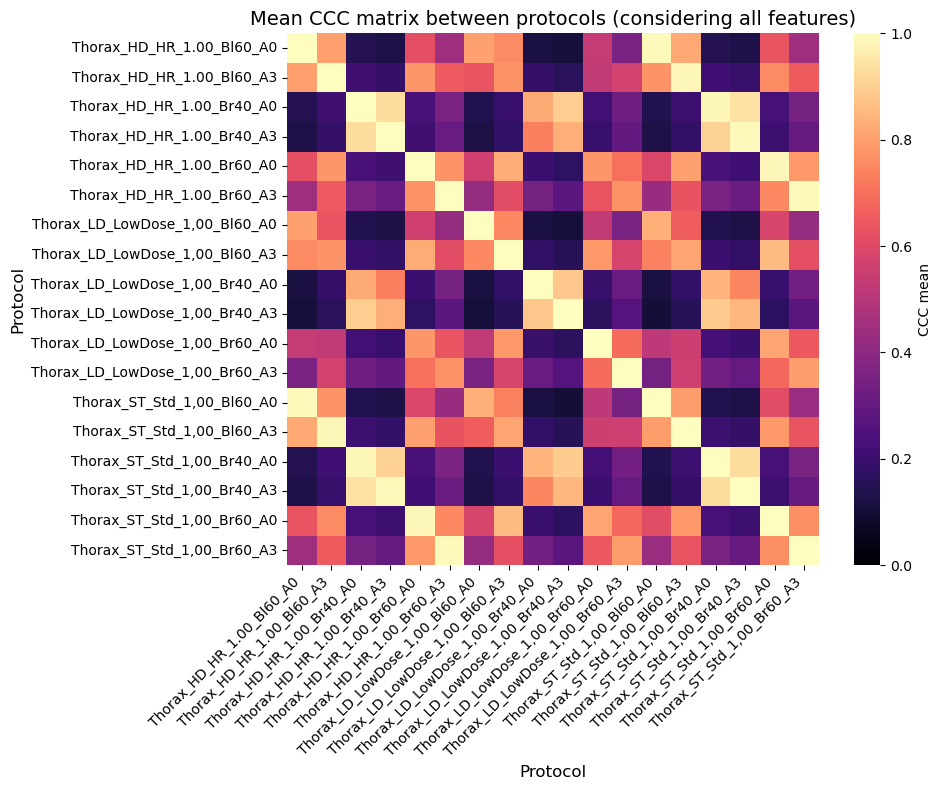

✓ Figura CCC heatmap salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_heatmap.png


In [ ]:


PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
csv_mat = PROJECT_DIR / "THORAX_CCC_matrix_protocols.csv"

df_mat = pd.read_csv(csv_mat, index_col=0)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(df_mat, vmin=0, vmax=1, cmap="magma",
            annot=False, square=True, cbar_kws={'label': 'CCC mean'},
            ax=ax)

ax.set_title("Mean CCC matrix between protocols (considering all features)", fontsize=14)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("Protocol", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
out_png = PROJECT_DIR / "THORAX_CCC_matrix_heatmap.png"
plt.savefig(out_png, dpi=300)
plt.show()
print("✓ Figura CCC heatmap salvata in:", out_png)


In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
df = pd.read_csv(PROJECT_DIR / "THORAX_mean_feature_per_protocol.csv")

# Estrai la classe di feature dal nome: original_glcm_... -> glcm
def get_feature_class(name):
    parts = name.split('_')
    if len(parts) > 1:
        return parts[1]
    return 'other'

df['feature_class'] = df['feature'].apply(get_feature_class)

prots = sorted(df["protocol"].unique())
features = sorted(df["feature"].unique())

def ccc(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    #cov_xy = np.mean((x - mean_x) * (y - mean_y))
    cov_xy = np.cov(x, y, ddof=1)[0, 1]
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y)**2)

rows = []

for p1, p2 in itertools.combinations(prots, 2):
    for feat in features:
        df1 = df[(df["protocol"] == p1) & (df["feature"] == feat)]
        df2 = df[(df["protocol"] == p2) & (df["feature"] == feat)]

        merged = pd.merge(df1, df2, on="roi", suffixes=("_p1", "_p2"))
        if len(merged) < 2:
            continue

        x = merged["mean_feature_p1"].values
        y = merged["mean_feature_p2"].values

        coeff = ccc(x, y)
        feat_class = get_feature_class(feat)

        rows.append({
            "protocol_1": p1,
            "protocol_2": p2,
            "feature": feat,
            "feature_class": feat_class,
            "ccc": coeff,
            "n_roi": len(x)
        })

df_ccc = pd.DataFrame(rows)

out_ccc = PROJECT_DIR / "THORAX_CCC_between_protocols_by_feature.csv"
df_ccc.to_csv(out_ccc, index=False)

print(f"✓ Salvati {len(df_ccc)} CCC per feature in: {out_ccc}")
print("Classi di feature trovate:", sorted(df_ccc['feature_class'].unique()))


✓ Salvati 14229 CCC per feature in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_between_protocols_by_feature.csv
Classi di feature trovate: ['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm']


Classi di feature: ['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm']
✓ Salvata matrice CCC per classe 'firstorder' in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_firstorder.csv


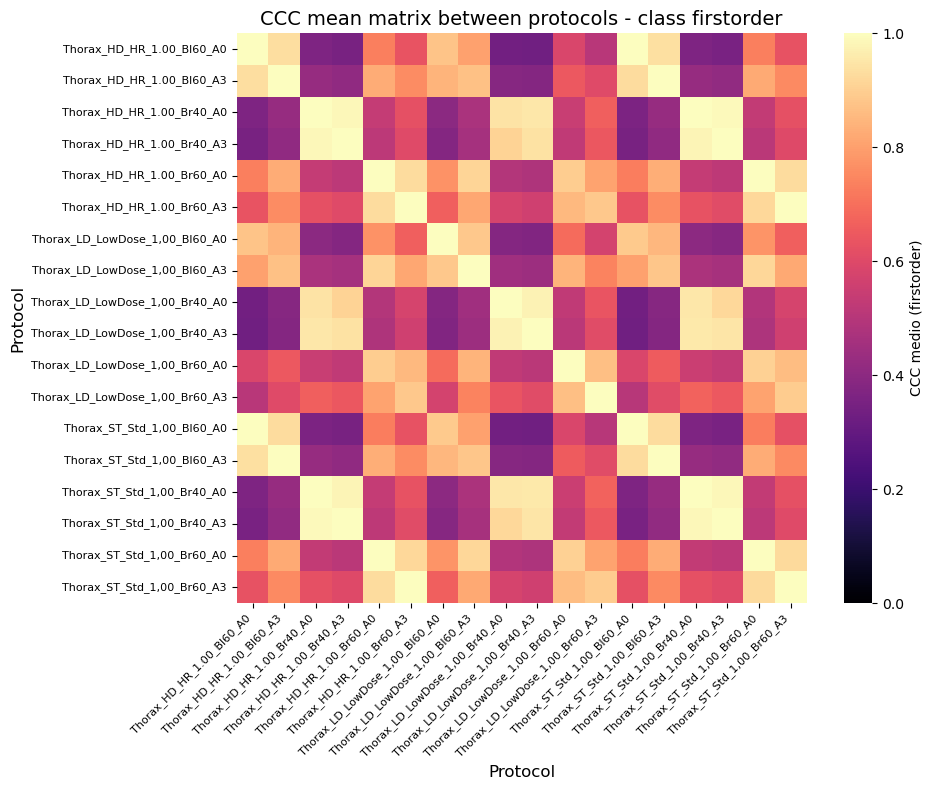

✓ Heatmap CCC per classe 'firstorder' salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_heatmap_firstorder.png

✓ Salvata matrice CCC per classe 'glcm' in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_glcm.csv


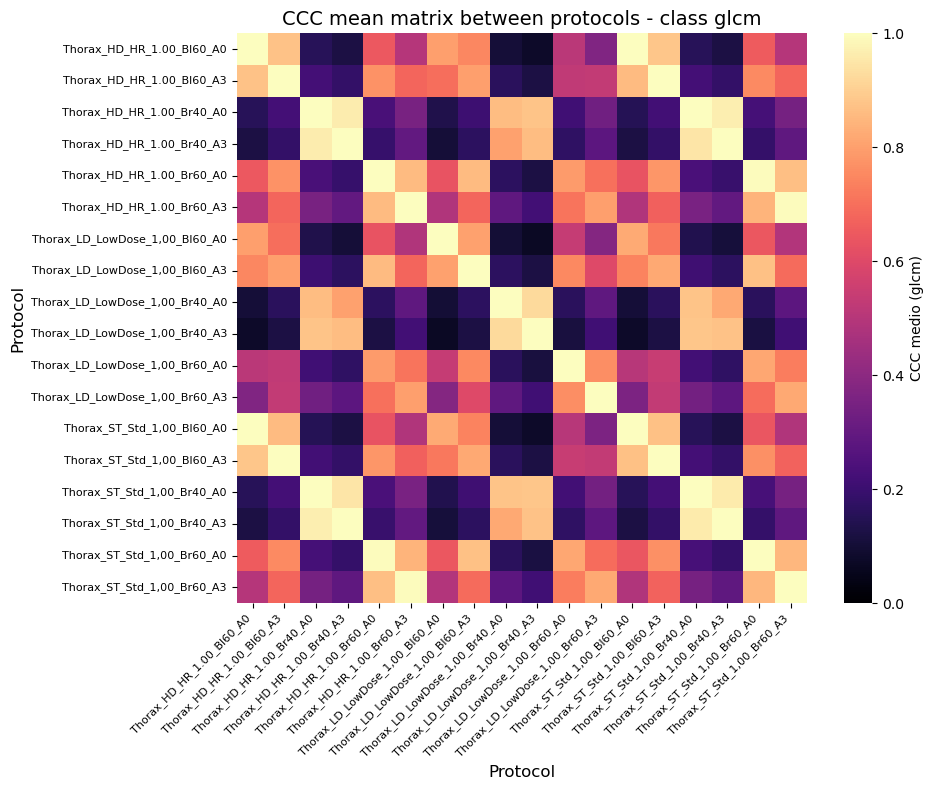

✓ Heatmap CCC per classe 'glcm' salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_heatmap_glcm.png

✓ Salvata matrice CCC per classe 'gldm' in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_gldm.csv


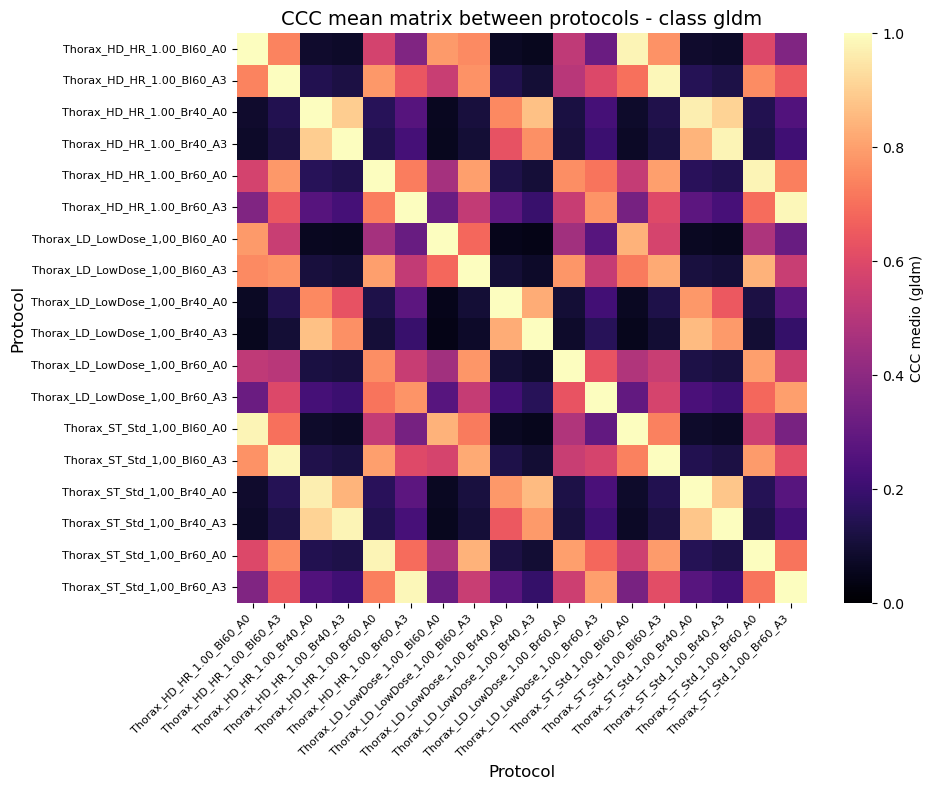

✓ Heatmap CCC per classe 'gldm' salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_heatmap_gldm.png

✓ Salvata matrice CCC per classe 'glrlm' in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_glrlm.csv


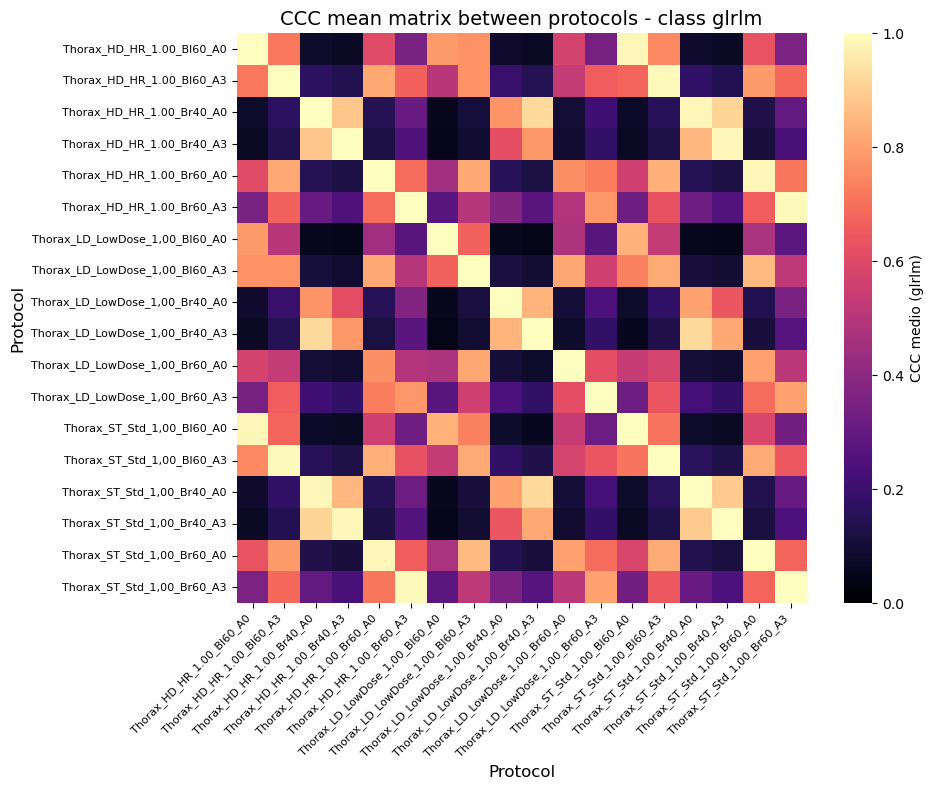

✓ Heatmap CCC per classe 'glrlm' salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_heatmap_glrlm.png

✓ Salvata matrice CCC per classe 'glszm' in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_glszm.csv


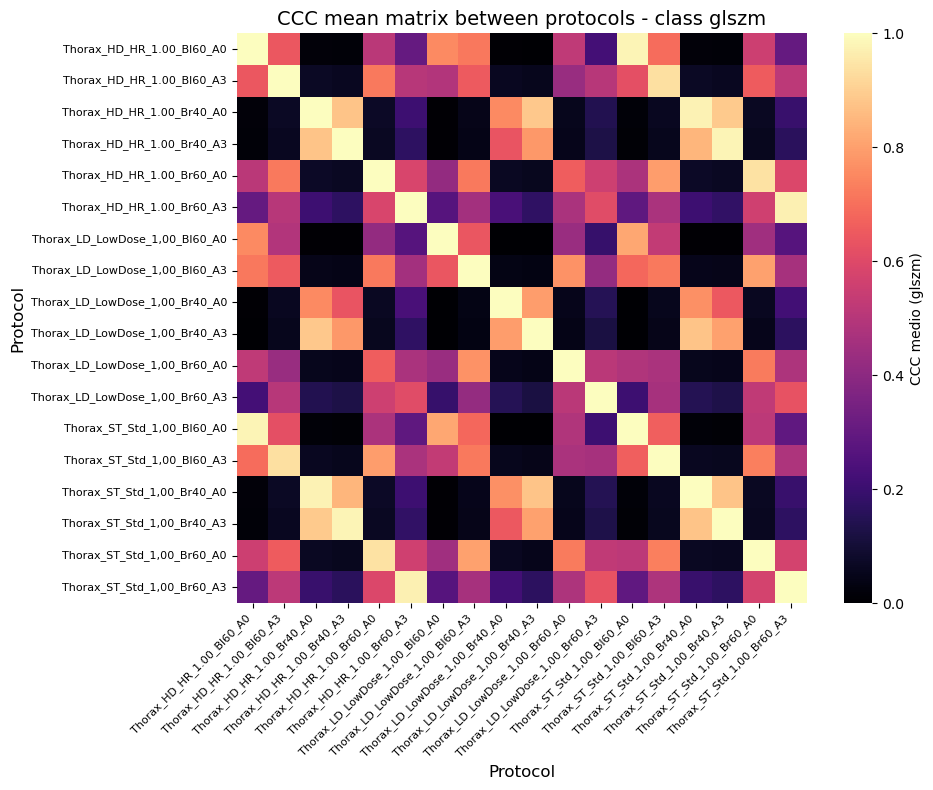

✓ Heatmap CCC per classe 'glszm' salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_heatmap_glszm.png

✓ Salvata matrice CCC per classe 'ngtdm' in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_matrix_ngtdm.csv


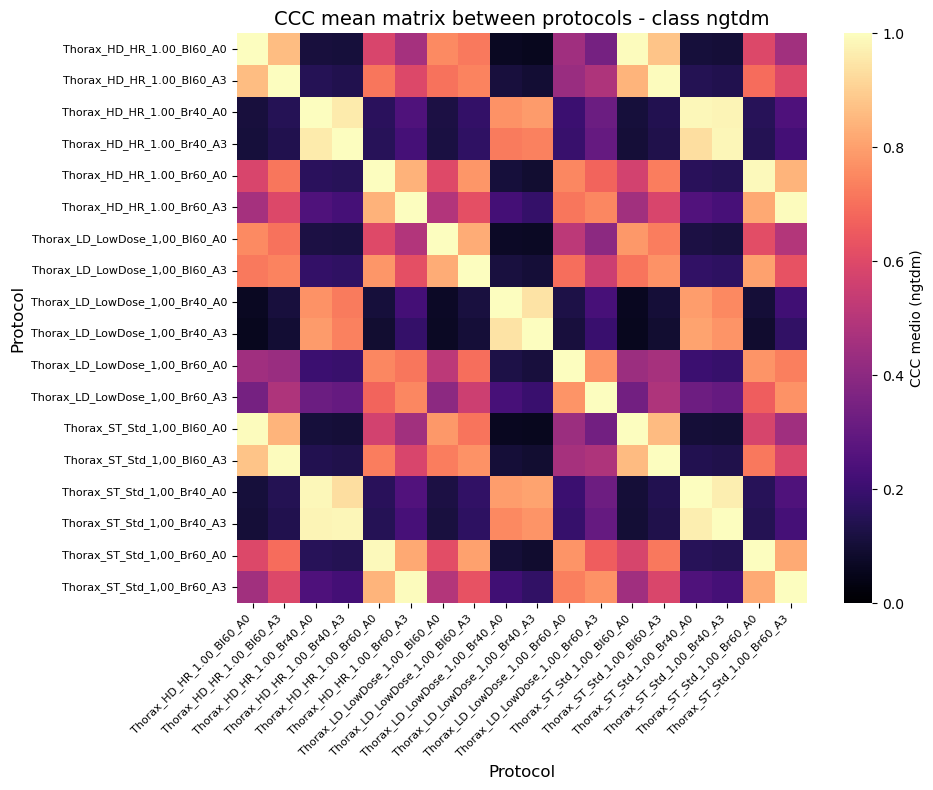

✓ Heatmap CCC per classe 'ngtdm' salvata in: /Users/irenetenerani/Desktop/RadiomiK/Radiomica/Thorax_Analisi_Radiomica/THORAX_CCC_heatmap_ngtdm.png



In [ ]:

PROJECT_DIR = Path("../RadiomiK/Radiomica/Thorax_Analisi_Radiomica")
df_ccc = pd.read_csv(PROJECT_DIR / "THORAX_CCC_between_protocols_by_feature.csv")

prots = sorted(set(df_ccc["protocol_1"]).union(df_ccc["protocol_2"]))
P = len(prots)

feature_classes = sorted(df_ccc["feature_class"].unique())
print("Classi di feature:", feature_classes)

for feat_class in feature_classes:
    df_c = df_ccc[df_ccc["feature_class"] == feat_class].copy()
    if df_c.empty:
        continue

    # matrice CCC medio per questa classe
    M = np.ones((P, P))

    for i, pi in enumerate(prots):
        for j, pj in enumerate(prots):
            if i == j:
                M[i, j] = 1.0
            elif i < j:
                sub = df_c[(df_c["protocol_1"] == pi) & (df_c["protocol_2"] == pj)]
                if sub.empty:
                    val = np.nan
                else:
                    val = sub["ccc"].mean()
                M[i, j] = val
                M[j, i] = val

    df_mat = pd.DataFrame(M, index=prots, columns=prots)
    out_mat = PROJECT_DIR / f"THORAX_CCC_matrix_{feat_class}.csv"
    df_mat.to_csv(out_mat)
    print(f"✓ Salvata matrice CCC per classe '{feat_class}' in: {out_mat}")

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        df_mat,
        vmin=0, vmax=1,
        cmap="magma",
        square=True,
        cbar_kws={"label": f"CCC medio ({feat_class})"},
        ax=ax
    )
    ax.set_title(f"CCC mean matrix between protocols - class {feat_class}", fontsize=14)
    ax.set_xlabel("Protocol", fontsize=12)
    ax.set_ylabel("Protocol", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)

    plt.tight_layout()
    out_png = PROJECT_DIR / f"THORAX_CCC_heatmap_{feat_class}.png"
    plt.savefig(out_png, dpi=300)
    plt.show()
    print(f"✓ Heatmap CCC per classe '{feat_class}' salvata in: {out_png}\n")
